# Tutorial 2: The cortical rate-scale representation with aud2cor
 
The mammalian auditory system starts its sound analysis in the cochlea by extracting time-varying frequency information from incoming sound waves (see `wav2aud`). Thereafter, subcortical nuclei and the primary auditory cortex extract regularities in the spectral and temporal variations obtained from the cochlea (`aud2cor`). The function `aud2cor` aims to mimic this process using modulation transfer functions calibrated on physiological data from the ferret brain. [[1](#References)]
 
While `aud2cor` could perform a 2-dimensional convolution with two physiologically tuned filter banks in the time-frequency domain, it implements these computations in the 2D modulation frequency domain where convolution simplifies to element-wise multiplication. This significantly enhances computational efficiency and filter design flexibility. The algorithm works as follows:
 
- **Input Representation**: The input to `aud2cor` is an auditory spectrogram (audiogram) representing energy across time and frequency, modeled after mammalian/ferret auditory processing. It is a real-valued matrix of shape [$N, M$], where $N$ is the number of frequency channels and $M$ is the number of time points.
 
- **Zero-Padding**: The dimensions of the audiogram are padded to the next highest power of 2, yielding a shape of [$N_{pad}, M_{pad}$], where $N_{pad}$ is the padded frequency axis and $M_{pad}$ is the padded time axis. This optimizes Fast Fourier Transform (FFT) efficiency. Next, the time axis is zero-padded by an additional factor of 2, yielding a shape of [$2 \cdot N_{pad}, M_{pad}$]. This extra space prevents circular convolution aliasing along the temporal axis when filtering and transforming back. It is applied only along the time axis because here, positive and negative temporal rates will be explicitly separated into distinct directional channels, whereas along the frequency axis, only the positive spectral scales are retained in memory.
 
- **2D Fast Fourier Transform**: A 2D FFT is applied to the padded spectrogram—first along the time axis, and then along the frequency axis. This maps the time-frequency domain into the 2D modulation frequency domain ($\omega, \Omega$), capturing temporal rates $\omega$ (vertical pattern changes over time, in Hz) and spectral scales $\Omega$ (horizontal pattern changes across frequency, in cycles/octave). The resulting 2D modulation spectrum has shape [$2 \cdot N_{pad}, M_{pad}$], representing the frequencies at which temporal and spectral regularities occur (i.e., how narrow or wide the spectrotemporal ripples are). Only the positive spectral frequencies are stored, which implicitly drops Hermitian conjugate symmetry.
 
- **Cortical Filter Bank Application**: To mirror spectrotemporal modulation sensitivities in the early auditory system of mammals, the 2D modulation spectrum is filtered using two banks of transfer functions calibrated to match recordings of the ferret primary auditory cortex:
    - **Temporal Filters (`HR`)**: Provided by `gen_cort`, which produces a complex-value transfer function. These bandpass filters isolate specific temporal rates (Hz).
    - **Spectral Filters (`HS`)**: Generated by `gen_corf`, which produces a real-valued transfer function. These bandpass filters isolate specific spectral scales (cycles/octave). 
 
  Multiplying the 2D modulation spectrum by all combinations of scales and signed (positive/negative) rates yields $K_2 \times (K_1 \cdot 2)$ filtered 2D matrices.
 
- **Inverse 2D FFT and Separable Processing**: Because the spectrotemporal filters are mathematically separable, the inverse 2D FFT (IFFT) is applied sequentially:
    1. The spectrum is multiplied by the temporal filters `HR`. This is done separately for positive and negative rate filters (downward vs. upward sweeps), which now also breaks Hermitian symmetry along the temporal axis. The result is transformed via a 1D IFFT along time to produce a complex-valued analytic signal, which is then cropped from $2 \cdot N_{pad}$ back down to $N + 2 \cdot dN$ time-frames, where $dN = \left \lceil{\frac{N}{2} \times \textrm{temporal margin}}\right \rceil$ is a left and right padding chosen by the user via the `temporal margin` argument (see below).
    2. The intermediate output is multiplied by the spectral filters `HS` and transformed via a 1D IFFT along the frequency axis. Because negative spectral frequencies were zeroed out previously, this step also yields complex-valued analytic signals. The output is cropped back down to $M + 2 \cdot dM$ frequency channels, where $dM = \left \lceil{\frac{M}{2} \times \textrm{spectral margin}}\right \rceil$ is a left and right padding chosen by the user via the `spectral margin` argument (see below).
 
- **Output Representation**: The final output is the cortical representation (`cr`), a 4D complex-valued tensor of shape [$num\_scales, num\_rates \cdot 2, N + 2 \cdot dN, M + 2 \cdot dM$]. This restores the original time-frequency coordinates while decomposing every bin into its underlying scale, rate, and directional sweep modulation channels.

### **About the filters**

The rate-scale decomposition described above is carried out by two banks of transfer functions as described above. The wavelet transform is implemented as a multiplication in the modulation-frequency domain, which is equivalent to a convolution in the equivalent temporal domain, but is computationally much cheaper.

**Interpreting the output of `aud2cor`:**
Each channel of `cr` comes from one temporal filter (`HR`, from `gen_cort`) paired with one spectral filter (`HS`, from `gen_corf`).
Although gen_cort returns a complex transfer function and gen_corf returns a real one, `cr` is still complex-valued. But the output cr is complex regardless. That's because aud2cor breaks Hermitian symmetry along both axes: it splits positive and negative rates into separate directional channels (time), and keeps only positive scales (frequency). Both IFFTs therefore return complex analytic signals rather than real values.

So every (scale, rate, time, freq) bin has a magnitude and a phase:

|cr| = how strongly a ripple at that rate and scale is present at that time-frequency location.
angle(cr) = the instantaneous phase of the analytic signal at that time-frequency location.
For example, if a ripple at a particular pair (rate, scale) is a sinusoid $A * cos(2πft + φ)$, then angle(cr) is the phase $φ$

Two bins with equal magnitude but different phase carry the same modulation strength; they differ only in where the ripple's peaks and troughs sit relative to that location.
---
Some important features of the filter bank are illustrated in the *Alternative configurations* section.

## **Using aud2cor**

This tutorial loads an audio file from one of the examples and creates an audiogram, as in Tutorial 1, which is then passed to `aud2cor`.

Parameters specific to `aud2cor` are:

- `tp_margin`: controls how much temporal margin is added around the representation.
- `sp_margin`: controls how much spectral margin is added around the representation.
- `bandpass`: changes the passband of the filters.
- `tpfilt_cf`: defines the center frequencies of the temporal modulation filters.
- `spfilt_ripples`: defines the center frequencies of the spectral modulation filters.
- `fname`: if given, writes the complex output to a binary file.

The parameters for `wav2aud` can still be passed in, and these will be used to write the header of the binary file.

For most exploratory work, the defaults are a good place to start.

### **Step 1: Generate audiogram**
Following the same steps as in Tutorial 1, an example sound can be selected using the dropdown menu and its audiogram generated using `wav2aud`.

In [1]:
from neural_audio.examples.sounds.load import load_sound_file_paths2
import soundfile as soundf
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display, Audio

# Get list of sound files. To get synthetic sounds, set synthetic=True, otherwise natural sounds will be used.
sound_files = load_sound_file_paths2(synthetic=False)
sound_file_names = [Path(file).name for file in sound_files]

# Create dropwdown widget to select and play sound file
dropdown = widgets.Dropdown(options=sound_file_names, description='Sound file:')
audio_player = widgets.Output()
sound_file_path = sound_files[1]

def on_change(change):
    if change['type'] == 'change' and change['name'] == 'value':
        global sound_file_path
        for file in sound_files:
            if Path(file).name == change['new']: sound_file_path = file
        audio_player.clear_output()
        with audio_player:
            display(Audio(str(sound_file_path), autoplay=False))

dropdown.observe(on_change)
dropdown.value = sound_file_names[1]  # Set default value to the first sound file
display(dropdown, audio_player)

Dropdown(description='Sound file:', index=1, options=('cardboard tapping.wav', 'cardboard whirling.wav', 'gees…

Output()

Audiogram shape == [750 frequencies, 128 time points]


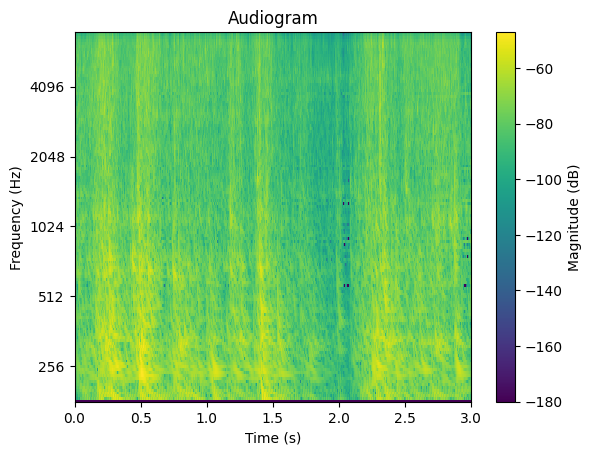

In [2]:
from neural_audio.wav2aud import wav2aud
from neural_audio.utils.visualize_outputs import plot_spectrogram
from neural_audio.aud2cor import aud2cor
import numpy as np
from neural_audio.utils.visualize_outputs import plot_cr_projection


# Compute an audiogram with default parameters
waveform, sampling_rate = soundf.read(sound_file_path)
time_points_audiogram, frequencies_audiogram, audiogram  = wav2aud(waveform)

print(f"Audiogram shape == [{audiogram.shape[0]} frequencies, {audiogram.shape[1]} time points]")

# For convenience, visualize the output
plot_spectrogram(audiogram, time_points_audiogram, frequencies_audiogram, title='Audiogram')


### **Step 2: Generate cortical representation**
To get the correct output dimensions, the **transpose** of the audiogram must be passed as input to `aud2cor`. Since default parameters were used for `wav2aud`, it is safe to also use the defaults for `aud2cor`. Note that **this step is far more computationally intensive and may take a few minutes**.

In [3]:
cr = aud2cor(audiogram)
print(f"Cortical representation shape: {cr.shape}")

num_scales, num_rate_channels, n_time, n_freq = cr.shape
print(f"Number of scales: {num_scales}")
print(f"Number of rate channels (rates x 2 directions): {num_rate_channels}")
print(f"Time frames: {n_time}")
print(f"Frequency frames: {n_freq}")

Cortical representation shape: (32, 64, 750, 128)
Number of scales: 32
Number of rate channels (rates x 2 directions): 64
Time frames: 750
Frequency frames: 128


### **Step 3: Visualization**
The output of `aud2cor` has four dimensions: scale, rate, time, and frequency. Because of this, it is useful to create 2D projections along specific axes. The function `plot_cr_projection` from utils does exactly this. It requires the following arguments:
- `cr` - The cortical representation (output of aud2cor), an array [scale x rate x time x frequency]
- `rates` - The rate vector used to construct the cortical representation
- `scales` - The scale vector used to construct the cortical representation
- `frequencies`- The audiogram frequencies

(<Figure size 1200x400 with 6 Axes>,
 (<Axes: title={'center': 'Scale-Rate'}, xlabel='Rate [Hz]', ylabel='Scale [cyc/oct]'>,
  <Axes: title={'center': 'Scale-Frequency'}, xlabel='Frequency [Hz]', ylabel='Scale [cyc/oct]'>,
  <Axes: title={'center': 'Rate-Frequency'}, xlabel='Frequency [Hz]', ylabel='Rate [Hz]'>))

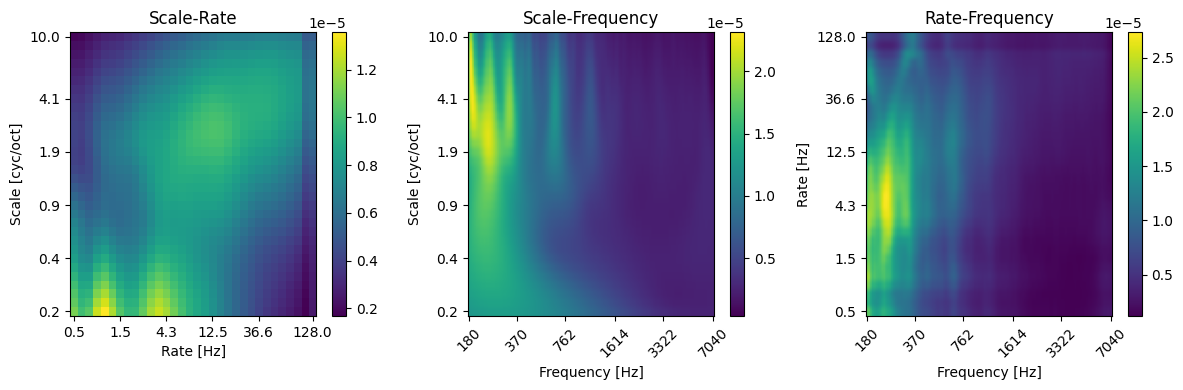

In [7]:
rates = 2 ** np.linspace(np.log2(0.5), np.log2(128), 32)
scales = 2 ** np.linspace(np.log2(1/5), np.log2(10), 32)
plot_cr_projection(cr, rates, scales=scales, frequencies=frequencies_audiogram)

## **Alternative configurations**
This section will cover the role of the following key parameters and how to adjust them beyond the defaults:
- `sp/tp_margin`
- `bandpass`
- `rates` and `scales`

> **Note on resolution:** Rather than using the default resolution of 32 rates x 32 scales, **from this point onwards, examples will be computed at a reduced resolution of 16 rates x 16 scales** to save on memory usage. This is sufficient to illustrate the desired behavior.

---
### **Temporal and spectral margins**
The output array of `aud2cor` has dimensions `(num_scales, num_rates * 2, N + 2 * dN, M + 2 * dM)`. `num_rates` is multiplied by two to account for both upwards and downwards directions. `dM` and `dN` are the margins applied symmetrically to the time and frequency axis, controlled by the parameters `sp_margin` and `tp_margin`.

##### **Theoretical background**
In the main loop of aud2cor, a 2D wavelet transform is performed, where the signal is convolved with a wavelet, first along the temporal and then along the log-frequency axis. It is the filter-generating functions that supply this wavelet (more detail on this in later sections).

A wavelet transform convolves the signal with a wavelet, which essentially evaluates "at this position, how similar is the signal to this wavelet?". Because a wavelet is not a single point, it can extend beyond the edges of the signal, which is why zero-padding is used to handle those edges.

The result of convolving a wavelet with these padding zeroes is generally of little use, except when the original signal must be reconstructed later. The padding can also be useful to avoid edge artifacts or to ensure all relevant information is included. However, the larger the margins, the longer the computation time. **Unless explicitly necessary for your use case, it is recommended to keep the margins at zero (default) to avoid adding unnecessary computational costs.**

##### **Usage**
`sp_margin` and `tp_margin` control the temporal and spectral margins and must be a real number between 0 and 1. These values determine the margin index used to extract the relevant values from the wavelet transform. The margin is applied symmetrically to either side of the main spectral content.

The margin index (`dM` or `dN`) is calculated according to

$$dM = \left \lceil{\frac{M}{2} \times \textrm{sp margin}}\right \rceil $$


(likewise for `N, tp_margin`). The maximum 'fullness' of the margin is roughly half the axis length. For example, given 20 time points, setting `tp_margin = 1` yields a margin index `dM` of 10. Given 21 time points, `dM` is also 10, due to the `ceil` operation.

##### **Example**
Below, the effect of adding a spectral margin is demonstrated.



In [12]:
half_rates = 2 ** np.linspace(np.log2(0.5), np.log2(128), 16)
half_scales = 2 ** np.linspace(np.log2(1/5), np.log2(10), 16)

In [13]:
cr_spectral_margin = aud2cor(audiogram, rates=half_rates, scales=half_scales, sp_margin=1)
print(f"Cortical representation shape, with spectral margin: {cr_spectral_margin.shape}")

cr_temporal_margin = aud2cor(audiogram, rates=half_rates, scales=half_scales, tp_margin=1)
print(f"Cortical representation shape, with temporal margin: {cr_temporal_margin.shape}")

cr_default = aud2cor(audiogram, rates=half_rates, scales=half_scales)
print(f"Cortical representation shape, without margins: {cr_default.shape}")


Cortical representation shape, with spectral margin: (16, 32, 750, 256)
Cortical representation shape, with temporal margin: (16, 32, 1500, 128)
Cortical representation shape, without margins: (16, 32, 750, 128)


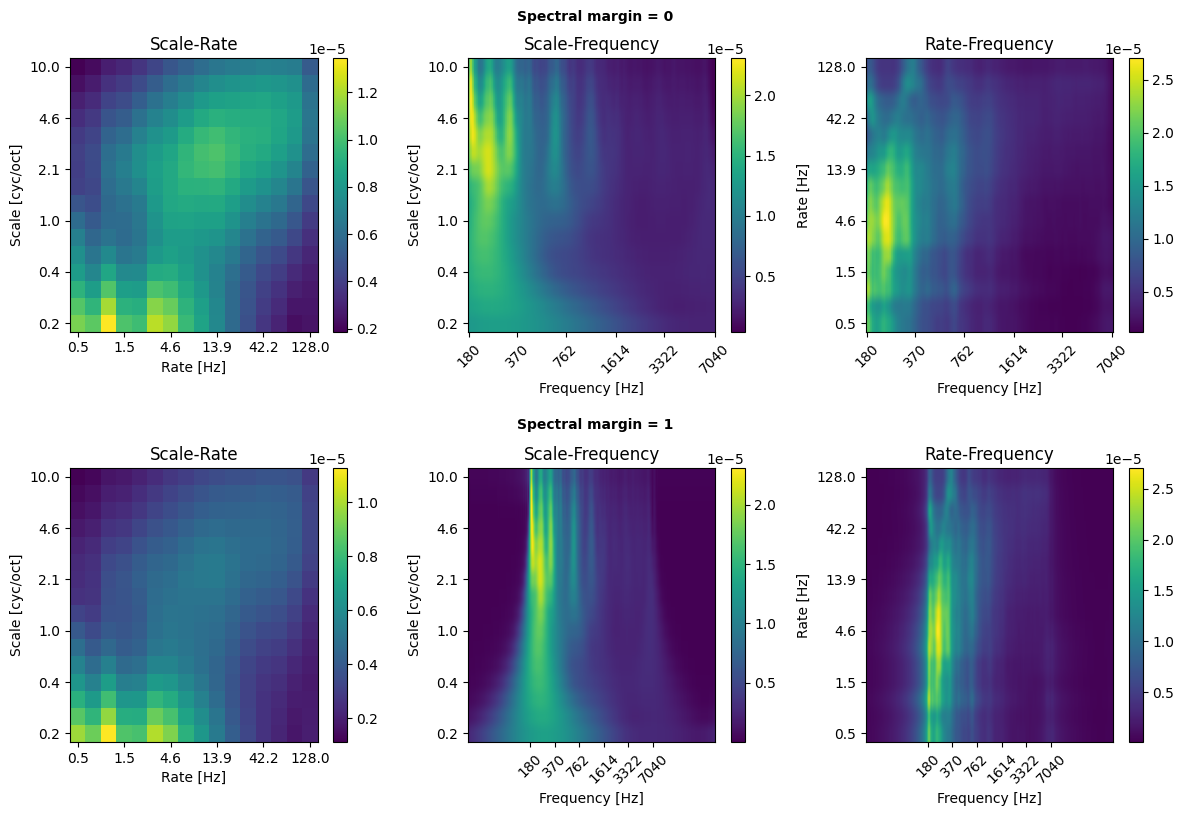

In [36]:
import matplotlib.pyplot as plt
fig, axs_grid = plt.subplots(2, 3, figsize=(12, 8))

plot_cr_projection(cr_default, half_rates, scales=half_scales, frequencies=frequencies_audiogram, axes=axs_grid[0])

plot_cr_projection(cr_spectral_margin, half_rates, scales=half_scales, frequencies=frequencies_audiogram, axes=axs_grid[1])

fig.text(0.5, 1, 'Spectral margin = 0', ha='center',  fontweight='bold')

fig.text(0.5, 0.49, 'Spectral margin = 1', ha='center', fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(hspace=0.5)

plt.show()

### **Rates and scales**
- The **rate** vector describes the temporal modulation rates used to construct the temporal filters (how fast a signal changes in time)
- The **scale** vector describes the spectral modulation rates used to construct the spectral filters (how fast the signal changes across frequency)

The plots below illustrate different synthetic signals constructed with simple spectral or temporal modulations, or both (a ripple).

In [18]:
# setup
from neural_audio.utils.mathfuncs import gen_spectral_modulations_scale, gen_temporal_modulations_rate, gen_ripple
from neural_audio.wav2aud import wav2aud
from neural_audio.utils.visualize_outputs import plot_spectrogram
import numpy as np
import matplotlib.pyplot as plt

scales = 2 ** np.linspace(np.log2(1/5), np.log2(10), 32) # default scales
rates = 2 ** np.linspace(np.log2(0.5), np.log2(64), 32) # default rates

#### Effect of rate on a temporally-modulated signal
This is an example of a signal that contains no spectral changes - all frequencies are present, but only in short bursts, meaning only temporal modulations are present.

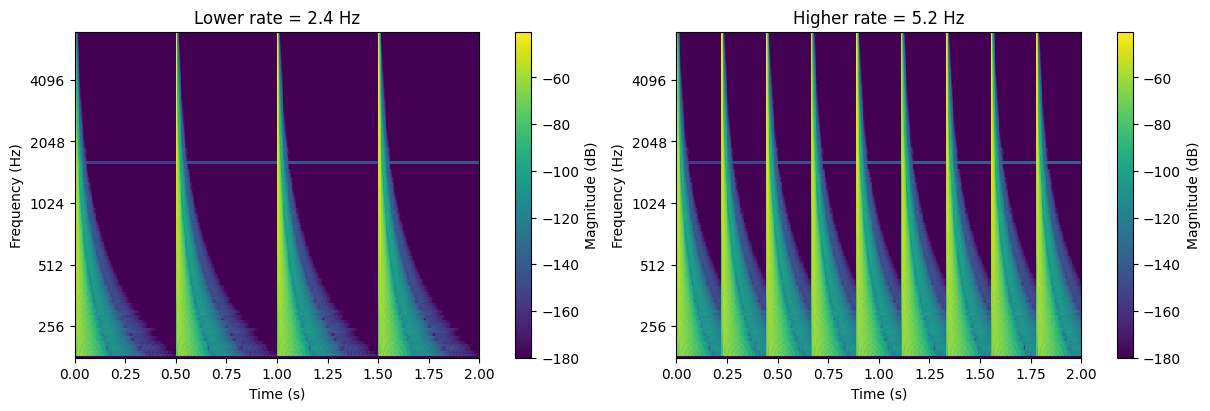

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

plt.sca(axes[0])
waveform = gen_temporal_modulations_rate(rates[10])
tp, freqs, aud = wav2aud(waveform)
plot_spectrogram(aud, tp, freqs, title=f"Lower rate = {rates[10]:.1f} Hz")

plt.sca(axes[1])
waveform = gen_temporal_modulations_rate(rates[15])
tp, freqs, aud = wav2aud(waveform)
plot_spectrogram(aud, tp, freqs, title=f"Higher rate = {rates[15]:.1f} Hz")

plt.show()

#### Effect of scale on a spectrally-modulated signal
Analogously to the above example, the signal below contains only spectral modulations. It is constant in time, but made up of various frequencies.

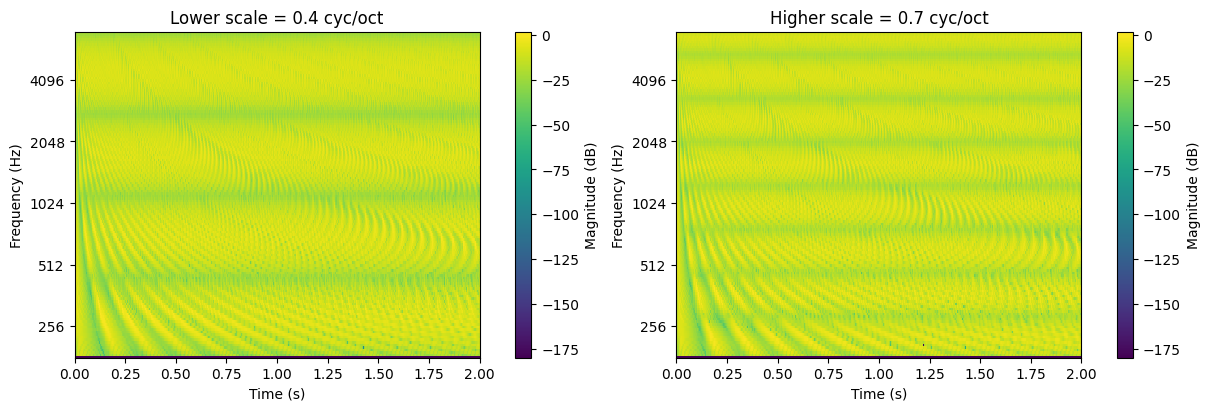

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

plt.sca(axes[0])
waveform = gen_spectral_modulations_scale(scales[5])
tp, freqs, aud = wav2aud(waveform)
plot_spectrogram(aud, tp, freqs, title=f"Lower scale = {scales[5]:.1f} cyc/oct")

plt.sca(axes[1])
waveform = gen_spectral_modulations_scale(scales[10])
tp, freqs, aud = wav2aud(waveform)
plot_spectrogram(aud, tp, freqs, title=f"Higher scale = {scales[10]:.1f} cyc/oct")

plt.show()

#### Effect of rate and scale on a ripple
Ripples are defined as "broadband noise with sinusoidally modulated spectrotemporal envelopes with different parameters"\[[1](#References)\]. In other words, this means the signal contains energy across a wide range of frequencies, but that energy is arranged in a sinusoidal pattern that varies across both time and frequency.

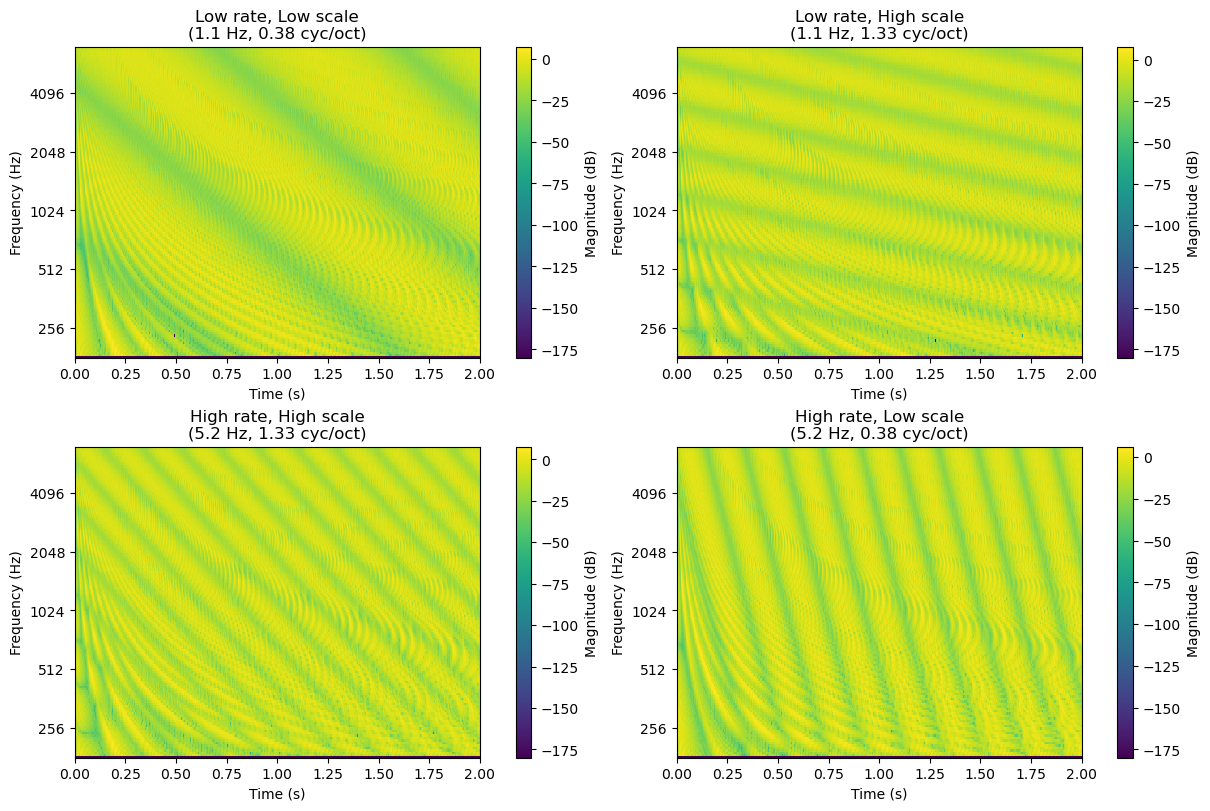

In [8]:
# Low/high values to illustrate the effect
low_rate  = rates[5]
high_rate = rates[15]

low_scale  = scales[5]
high_scale = scales[15]

configs = [
    (low_rate,  low_scale,  "Low rate, Low scale"),
    (low_rate,  high_scale, "Low rate, High scale"),
    (high_rate, high_scale, "High rate, High scale"),
    (high_rate, low_scale,  "High rate, Low scale"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

for ax, (rate, scale, title) in zip(axes.flat, configs):

    waveform = gen_ripple(rate=rate, scale=scale)

    t, freqs, aud = wav2aud(waveform)

    plt.sca(ax)
    plot_spectrogram(
        aud,
        t,
        freqs,
        title=f"{title}\n({rate:.1f} Hz, {scale:.2f} cyc/oct)"
    )

plt.show()

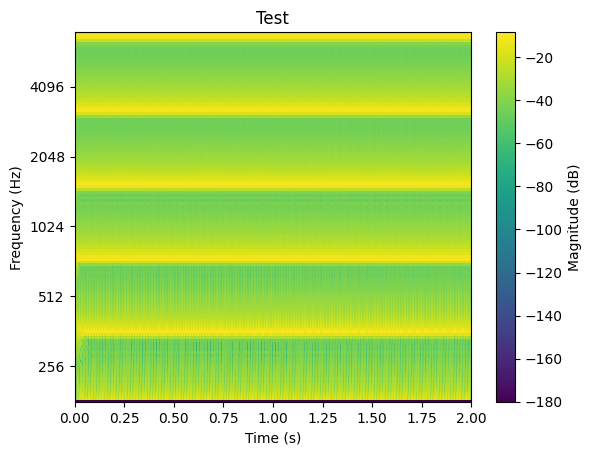

In [23]:
from neural_audio.utils.mathfuncs import gen_spectral_modulations
test_wave = gen_spectral_modulations()
tp, freqs, aud = wav2aud(test_wave)
plot_spectrogram(aud, tp, freqs, title=f"Test")

### **How the stimulus-generating functions work**

The synthetic signals above are produced by three helper functions in `neural_audio.utils.mathfuncs`. Each returns a 1-D waveform, which is then passed through `wav2aud` to produce the audiograms. Each is built based on known rate and/or scale parameters.

- **`gen_temporal_modulations_rate(rate)`: pure temporal modulation.** It places `round(rate * duration)` evenly spaced impulses along the time axis. An impulse contains all frequencies at once, so every frequency channel switches on and off together at the chosen `rate`. The audiogram therefore shows vertical bursts (temporal modulation) with no spectral structure.

- **`gen_spectral_modulations_scale(scale)`: pure spectral modulation.** It sums many log-spaced sinusoidal carriers with frequencies in the interval [`f_min`, `f_max`], which can be specified by the user. Each is weighted by a fixed amplitude $\sin(2\pi \cdot \text{scale} \cdot x)$, where $x$ is the carrier's position in octaves above `f_min`. This amplitude pattern repeats every $1/\text{scale}$ octaves, so the audiogram shows stationary horizontal stripes (spectral modulation) with no change over time. Each carrier is given a **random starting phase** so that neighbouring carriers do not beat coherently — without this, the coherent beating imprints a spurious, frequency-swept interference ("fingerprint") pattern on the audiogram.

- **`gen_ripple(rate, scale)`: a full spectrotemporal ripple.** It uses the same log-spaced carriers, but now each carrier's amplitude follows a *travelling* envelope $1 + A\,\sin(2\pi(\text{rate}\cdot t + \text{scale}\cdot x) + \Phi)$ that varies over both time and octave position. The result is a drifting diagonal ripple whose temporal speed is set by `rate` and whose spectral density is set by `scale`. This is the "broadband noise with sinusoidally modulated spectrotemporal envelope" of Chi et al. (2005). \[[1](#References)\]

These functions are useful for building intuition: feeding a signal with a known rate and scale into `aud2cor` makes it possible to confirm that energy appears in the expected rate and scale channels of the cortical representation.

---
### **Bandpass indicator**
The `bandpass` parameter controls the passbands of the filters produced by `gen_cort` and `gen_corf`. It is an integer flag (must be `0` or `1`). `True`/`False` are not accepted because the value is used directly in arithmetic when building the filter arguments.
- if `bandpass = 1`, only bandpass filters are generated.
- if `bandpass = 0`, a **lowpass** filter is generated for the first rate and scale, a **highpass** filter for the last rate and scale, and bandpass filters for all intermediate rate and scale values.

This is a global property: it affects *both* filter-generating functions at once. The shapes of the individual low/band/highpass filters are shown later, in *Exploring the filter bank → Plotting the frequency response*.

The figure below shows how this choice changes the full cortical representation. Because `bandpass = 0` turns the first and last filters into low- and highpass filters, the edge (lowest/highest) rate and scale channels also collect modulation energy that falls *outside* the bandpass range. In the projections this typically makes those edge channels noticeably brighter than in the bandpass-only case.

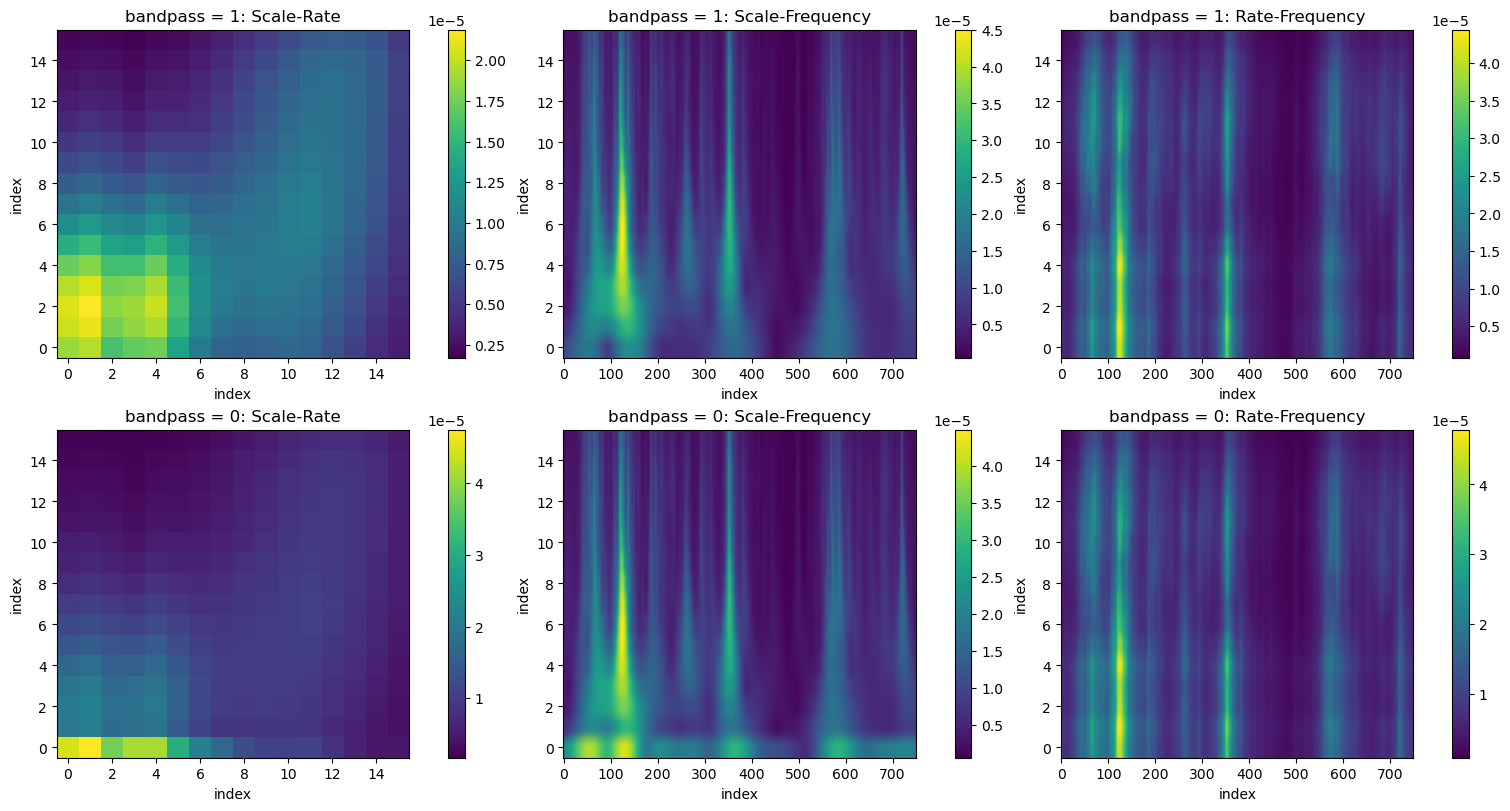

In [9]:
from neural_audio.aud2cor import aud2cor
import numpy as np
import matplotlib.pyplot as plt

# Reduced resolution (16 rates x 16 scales; see the note above). Two cortical
# representations are compared here, so a lower resolution than the primary
# example (32 x 32) is used to keep memory use and runtime manageable.
rates_bp  = 2 ** np.linspace(np.log2(0.5), np.log2(128), 16)
scales_bp = 2 ** np.linspace(np.log2(1/5), np.log2(10), 16)


def cr_projections(cr, n_rate):
    """Collapse a cortical representation to its three 2D projections (magnitude,
    time-averaged, directions combined) -> (scale-rate, scale-frequency, rate-frequency)."""
    avg = ((np.abs(cr[:, :n_rate]) + np.abs(cr[:, n_rate:])) / 2).mean(axis=2)  # [scale, rate, freq]
    return avg.mean(2), avg.mean(1), avg.mean(0)


# Compute one representation at a time and keep only its (small) projections, so the
# two full representations never sit in memory simultaneously.
proj_by_label = {}
for label, bp in [("bandpass = 1", 1), ("bandpass = 0", 0)]:
    cr_case = aud2cor(audiogram.T, bandpass=bp, rates=rates_bp, scales=scales_bp)
    proj_by_label[label] = cr_projections(cr_case, len(rates_bp))
    del cr_case

fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
proj_titles = ["Scale-Rate", "Scale-Frequency", "Rate-Frequency"]

for row, label in enumerate(["bandpass = 1", "bandpass = 0"]):
    for col, (data, ptitle) in enumerate(zip(proj_by_label[label], proj_titles)):
        ax = axes[row, col]
        im = ax.imshow(data, aspect="auto", origin="lower", cmap="viridis")
        ax.set_title(f"{label}: {ptitle}")
        ax.set_xlabel("index")
        ax.set_ylabel("index")
        fig.colorbar(im, ax=ax)

plt.show()

## **Exploring the filter bank**

The theory behind the temporal and spectral filters is covered at the start of the tutorial (see *About the filters*). This section visualises the actual frequency responses that `gen_cort` and `gen_corf` produce for a few example rates and scales, and compares the two available spectral-filter shapes.

In [10]:
# Global parameter setup and imports
from neural_audio.aud2cor import gen_cort, gen_corf
from neural_audio.utils.visualize_outputs import plot_tempfilt_response, plot_spectfilt_response
import matplotlib.pyplot as plt
import numpy as np

N, M = audiogram.T.shape # shape (timepoints, freq_channels)
# FFT Padding
N_pad = int(2 ** np.ceil(np.log2(N)))
M_pad = int(2 ** np.ceil(np.log2(M)))

scales = 2 ** np.linspace(np.log2(1/5), np.log2(10), 32) # default scales
rates = 2 ** np.linspace(np.log2(0.5), np.log2(64), 32) # default rates
fps = 1000 / 4 # frames per second, calculated with default num_frames
ch_per_oct = 20 if M == 95 else 24
num_rates, num_scales = len(rates), len(scales)

### **Plotting the frequency response**
The shape of the different filters is shown below for some example rates and scales. A few important notes:
- If `bp = 0` it is *always* the first index of the rate/scale that produces the lowpass filter and the last index that
    produces the highpass filter.
- The plots for temporal filters have different resolutions depending on what rate they are tuned to. This is an artifact
    from the choice of FFT bin relative to the bandwidth (which is proportional to the rate). It does not affect filter behavior.

NameError: name 'gen_cort' is not defined

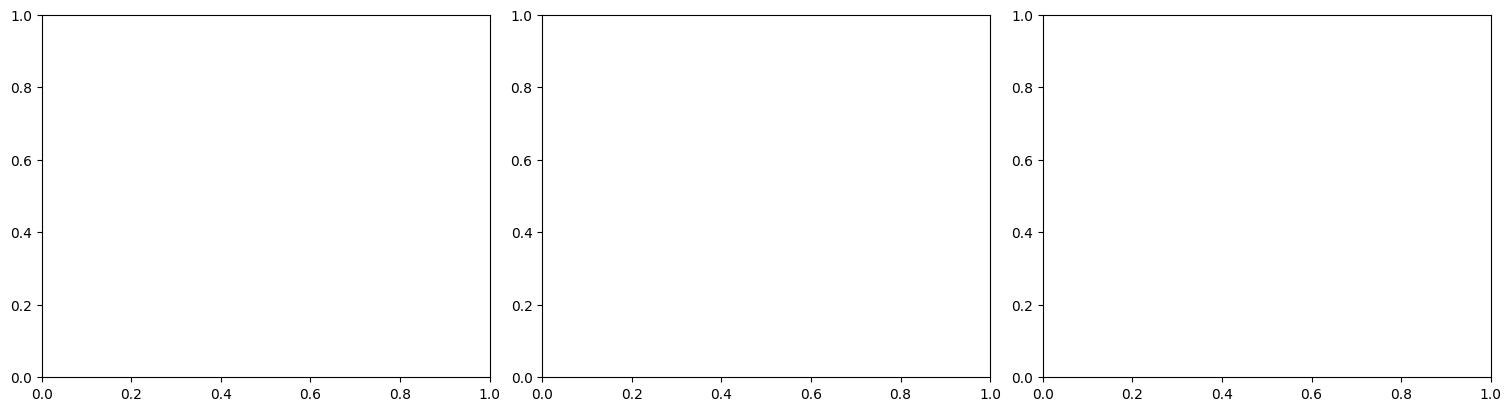

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
indexes_to_plot = [0, 10, num_rates-1]

for ax, rdx in zip(axes, indexes_to_plot):
    bp = 0
    H = gen_cort(rates[rdx], N_pad, fps, [rdx + 1 + bp, num_rates + bp * 2])
        
    _title = f"Bandpass: {rates[rdx]:g} Hz"
    _max_freq = 40
    if bp == 0:
        if rdx == 0:
            _title = f"Lowpass: {rates[rdx]:g} Hz"
            _max_freq = 40
        elif rdx == num_rates-1:
            _title = f"Highpass: {rates[rdx]:g} Hz"
            _max_freq = None
            

    plot_tempfilt_response(H, fps, center=rates[rdx], max_freq=_max_freq, title=_title, ax=ax)
 
plt.show()

The frequency responses of the spectral filters are shown below. Note that `bp = 0` is set here so that all filter shapes can be seen, although the default is `bp = 1` (all bandpass).

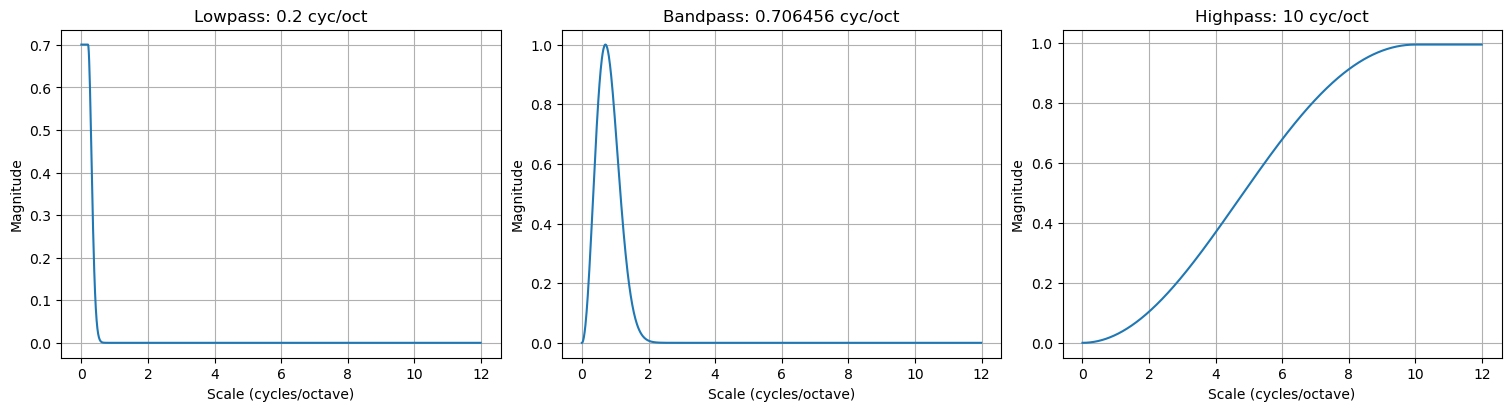

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
scales_to_plot = [scales[0], scales[10], scales[-1]]  # or whichever scales you want

for ax, scale in zip(axes, scales_to_plot):
    sdx = np.argmin(np.abs(scales - scale))
    bp = 0
    H = gen_corf(scales[sdx], M_pad, ch_per_oct,
                 PASS=[sdx + 1 + bp, num_scales + bp * 2])
    
    _title = f"Bandpass: {scales[sdx]:g} cyc/oct"
    if bp == 0:
        if sdx == 0:
            _title = f"Lowpass: {scales[sdx]:g} cyc/oct"
        elif sdx == num_scales-1:
            _title = f"Highpass: {scales[sdx]:g} cyc/oct"

    plot_spectfilt_response(
        H,
        ch_per_oct,
        title=_title,
        ax=ax
    )

plt.show()

### **Choosing the spectral filter shape (`func_type`)**

Two functions can be used to derive the spectral transfer function in `gen_corf`:
- A **Gabor** function
    $$ e^{-C (x-1)^2} + e^{-C (x+1)^2} $$

- A **Gaussian** function (the negative second derivative of a Gaussian)
    $$x^2 e^{(1-x^2)}$$

where $C$ is a constant and $x$ denotes the octave offset (channels per 0.5 cycles).

This is selected through the `func_type` argument, which takes the string `'gabor'` or `'gaussian'` (default `'gaussian'`). Below, an example is given for a bandpass filter using each, for the same scale, to illustrate the difference in the resulting filter's shape.

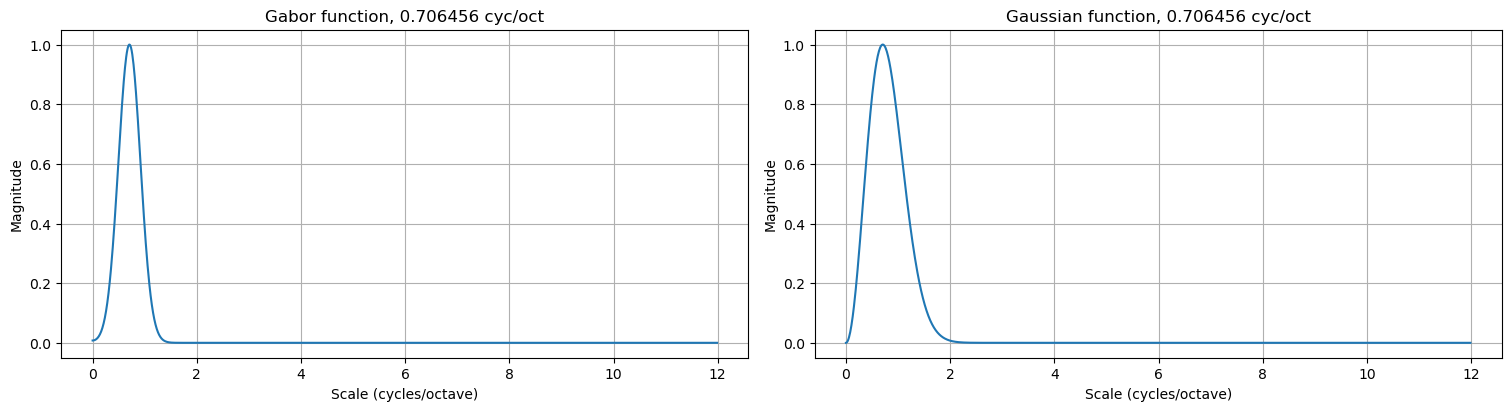

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4), constrained_layout=True)
func_options = ['gabor', 'gaussian']
for ax, func in zip(axes, func_options):
    sdx = 10 # arbitrarily chosen index
    H = gen_corf(scales[sdx], M_pad, ch_per_oct, func_type=func)

    _title = f"{func.capitalize()} function, {scales[sdx]:g} cyc/oct"

    plot_spectfilt_response(
        H,
        ch_per_oct,
        title=_title,
        ax=ax
    )

plt.show()

# References
[1] Chi, Taishih & Ru, Powen & Shamma, Shihab (2005),
        "Multiresolution spectrotemporal analysis of complex sounds" ,
        The Journal of the Acoustical Society of America, 118, 887-906, 
        10.1121/1.1945807